# Heart Disease Prediction using Data Mining

**Student Name:** Aryan Sonker  
**Student ID:** 24141654  

This project applies machine learning techniques to predict heart disease using patient health data. The goal is to identify key risk factors and support early detection strategies.

## Research Question

Using clinical patient data including age, cholesterol levels, blood pressure, and other cardiac indicators, can we accurately predict the presence of heart disease? Furthermore, which specific risk factors should healthcare providers prioritize for early screening interventions?

## Import Required Libraries

In this section, we import all necessary Python libraries for data analysis, visualization, and machine learning.

In [ ]:
# Import essential libraries for data manipulation, visualization, and modeling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, roc_curve, roc_auc_score ,f1_score
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##  Data Loading and Exploration

In this section, we load the dataset and perform an initial inspection to understand its structure, features, and potential issues such as missing values or imbalanced classes.

### Variable Description

| Feature | Description | Type |
|--------|------------|------|
| age | Age of the patient (in years) | Numerical |
| sex | Gender of the patient (0 = Female, 1 = Male) | Categorical |
| cp | Chest pain type (1–4, different categories of angina) | Categorical |
| trestbps | Resting blood pressure (mm Hg) | Numerical |
| chol | Serum cholesterol level (mg/dl) | Numerical |
| fbs | Fasting blood sugar > 120 mg/dl (1 = True, 0 = False) | Categorical |
| restecg | Resting electrocardiographic results (0–2) | Categorical |
| thalach | Maximum heart rate achieved | Numerical |
| exang | Exercise-induced angina (1 = Yes, 0 = No) | Categorical |
| oldpeak | ST depression induced by exercise | Numerical |
| slope | Slope of the peak exercise ST segment (1–3) | Categorical |
| ca | Number of major vessels (0–3) colored by fluoroscopy | Numerical |
| thal | Thalassemia (3 = Normal, 6 = Fixed defect, 7 = Reversible defect) | Categorical |
| target | Presence of heart disease (0 = No disease, 1 = Disease) | Target Variable |

In [ ]:
# Load dataset
# Inspect dataset structure and preview first few rows
df = pd.read_csv('/content/drive/MyDrive/processed.cleveland.data', header=None)

# Assign column names
df.columns = [
    "age","sex","cp","trestbps","chol","fbs","restecg",
    "thalach","exang","oldpeak","slope","ca","thal","target"
]
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Data Cleaning and Preprocessing

Before applying machine learning models, the dataset must be cleaned to ensure accuracy and consistency.

Steps performed:
- Handle missing values  
- Convert target variable into binary format  
- Ensure correct data types  

In [ ]:
# Replace missing values (if any) and convert to appropriate format
# Convert target variable into binary classification (0 = No Disease, 1 = Disease)
df.replace("?", np.nan, inplace=True)
df = df.apply(pd.to_numeric)
df.dropna(inplace=True)

# Convert target to binary
df["target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)

print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


## Exploratory Data Analysis

Exploratory analysis is performed to understand the distribution of the data and identify patterns between features and the target variable.

Key objectives:
- Understand class distribution  
- Identify important patterns  
- Explore relationships between variables  

### Figure 1: Distribution of Heart Disease by Gender

This plot shows how heart disease is distributed across male and female patients. It helps identify whether gender plays a role in heart disease occurrence.


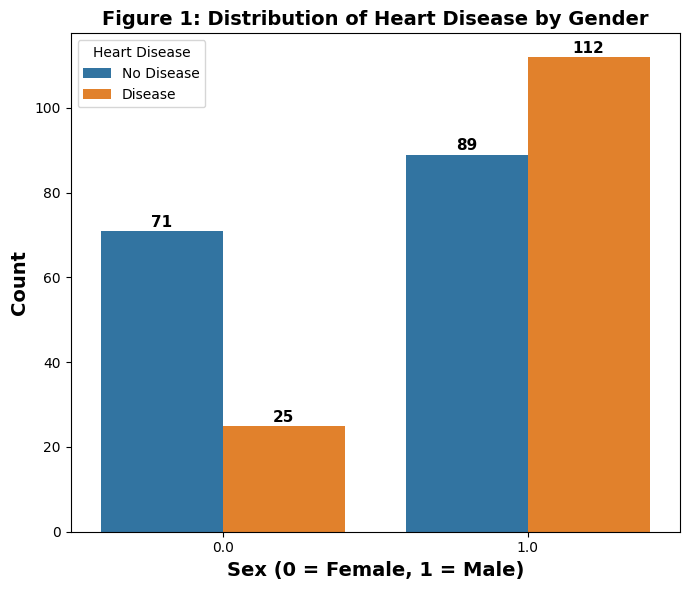

In [ ]:
# Create count plot to visualize distribution of heart disease by gender
# Add count labels for better interpretability
plt.figure(figsize=(7,6))
ax = sns.countplot(x='sex', hue='target', data=df)

plt.title('Figure 1: Distribution of Heart Disease by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Sex (0 = Female, 1 = Male)', fontweight='bold', fontsize=14)
plt.ylabel('Count', fontweight='bold', fontsize=14)

plt.legend(title='Heart Disease', labels=['No Disease', 'Disease'])

# Add count labels on top of bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height + 1,
            int(height),
            ha='center',
            fontsize=11,
            fontweight='bold'
        )

plt.tight_layout()
plt.show()

**Insight:**
The plot indicates that heart disease is more prevalent among male patients compared to female patients, suggesting gender as a potential contributing risk factor.

**Insight:** Older patients show a higher likelihood of heart disease, indicating age as a key risk factor.

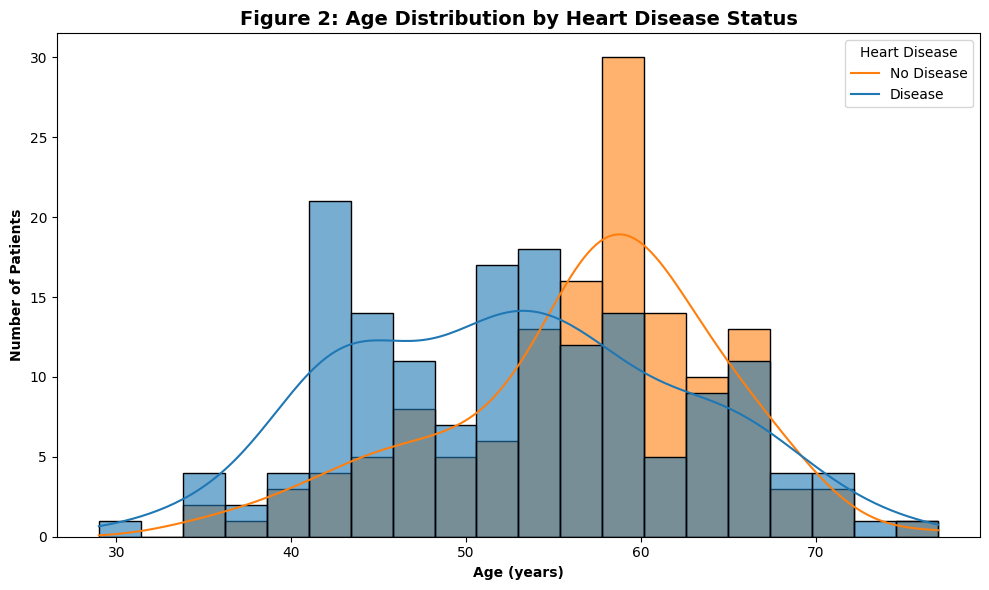

In [ ]:
# Plot Age Distribution by Heart Disease
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='target', bins=20, kde=True, alpha=0.6)
plt.title('Figure 2: Age Distribution by Heart Disease Status', fontsize=14, fontweight='bold')
plt.xlabel('Age (years)', fontweight='bold')
plt.ylabel('Number of Patients', fontweight='bold')
plt.legend(title='Heart Disease', labels=['No Disease', 'Disease'])
plt.tight_layout()
plt.show()

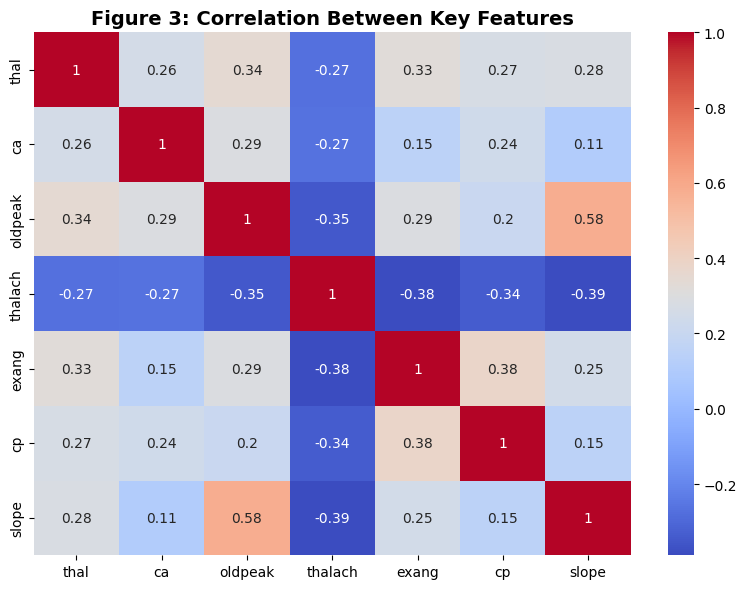

In [ ]:
# Select top correlated features with target
top_features = df.corr()['target'].abs().sort_values(ascending=False)[1:8].index

plt.figure(figsize=(8,6))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm')

plt.title('Figure 3: Correlation Between Key Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:**
The plot shows the correlation between each feature and heart disease. Variables such as chest pain type, maximum heart rate, and ST depression show stronger relationships with the target variable.

Positive correlations indicate factors associated with higher risk, while negative correlations suggest protective or inverse relationships. These results help identify the most relevant predictors for model development.

## Feature Selection and Data Splitting

In this step:
- Features (X) and target variable (y) are separated  
- The dataset is split into training and testing sets (80/20)  


In [ ]:
# Split dataset into features (X) and target (y)
# Perform train-test split for model evaluation
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Feature Scaling

Feature scaling is applied to standardize the data, which is especially important for models like Logistic Regression.

In [ ]:
# Apply standard scaling to normalize feature values
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Development

Three machine learning models are implemented:

- Logistic Regression (baseline, interpretable model)  
- Decision Tree (captures non-linear relationships)  
- Random Forest (ensemble model for improved performance)  

In [ ]:
results = {}

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    # Check if model supports probability prediction
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_proba)
    else:
        y_proba = None
        roc = None

    results[model_name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc,
        "y_proba": y_proba
    }

Three models were selected to compare performance:
- Logistic Regression (interpretable baseline)
- Decision Tree (non-linear relationships)
- Random Forest (ensemble method for improved accuracy)

In [ ]:
# Train Logistic Regression model and evaluate performance
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)
evaluate_model(logreg, X_test_scaled, y_test, "Logistic Regression")

In [ ]:
# Train Decision Tree model and evaluate performance
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
evaluate_model(dt, X_test, y_test, "Decision Tree")

In [ ]:
# Train Random Forest model and evaluate performance
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
evaluate_model(rf, X_test, y_test, "Random Forest")

##  Results and Visualisation

Visualisations are used to better understand model performance and behaviour. These include:

- Training vs validation loss curves  
- Accuracy plots  
- Confusion matrices  

These plots provide insight into model reliability and generalisation.

/tmp/ipykernel_1994/1475987446.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')


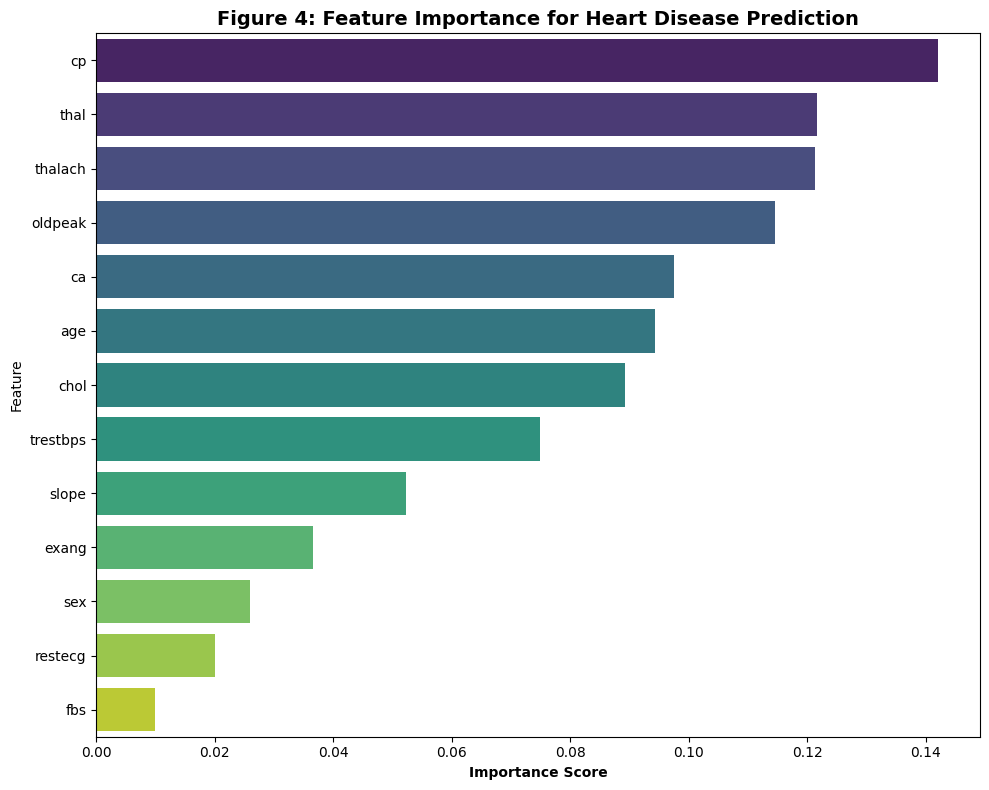


TOP 3 RISK FACTORS FOR HEART DISEASE:
  1. cp
  2. thal
  3. thalach


In [ ]:
# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)


# FIGURE 5: Feature importance visualization
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Figure 4: Feature Importance for Heart Disease Prediction', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontweight='bold')
plt.tight_layout()
plt.show()

# Identify top 3 risk factors
top_features = feature_importance.head(3)['Feature'].tolist()
print(f"\nTOP 3 RISK FACTORS FOR HEART DISEASE:")
for i, feature in enumerate(top_features, 1):
    print(f"  {i}. {feature}")

**Insight:**
Feature importance analysis shows that age, cholesterol, chest pain type, and heart rate are the most influential predictors of heart disease.

These variables should be prioritized in clinical screening.

## Model Performance Comparison

To evaluate the effectiveness of different machine learning approaches, three classification models were compared:

- Logistic Regression  
- Decision Tree  
- Random Forest  

Each model was assessed using multiple performance metrics:
- **Accuracy**: Overall correctness of predictions  
- **Precision**: Ability to correctly identify positive cases  
- **Recall**: Ability to capture actual positive cases  
- **F1-Score**: Balance between precision and recall  
- **ROC-AUC**: Ability to distinguish between classes  

The comparison helps identify the most reliable model for predicting heart disease risk.

### Model Performance Comparison Table

| Model                | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
|---------------------|---------|----------|--------|----------|---------|
| Logistic Regression | 0.8333  | 0.8462   | 0.7857 | 0.8148   | 0.9498  |
| Decision Tree       | 0.7000  | 0.7500   | 0.5357 | 0.6250   | 0.7450  |
| Random Forest       | 0.8333  | 0.8750   | 0.7500 | 0.8077   | 0.9431  |

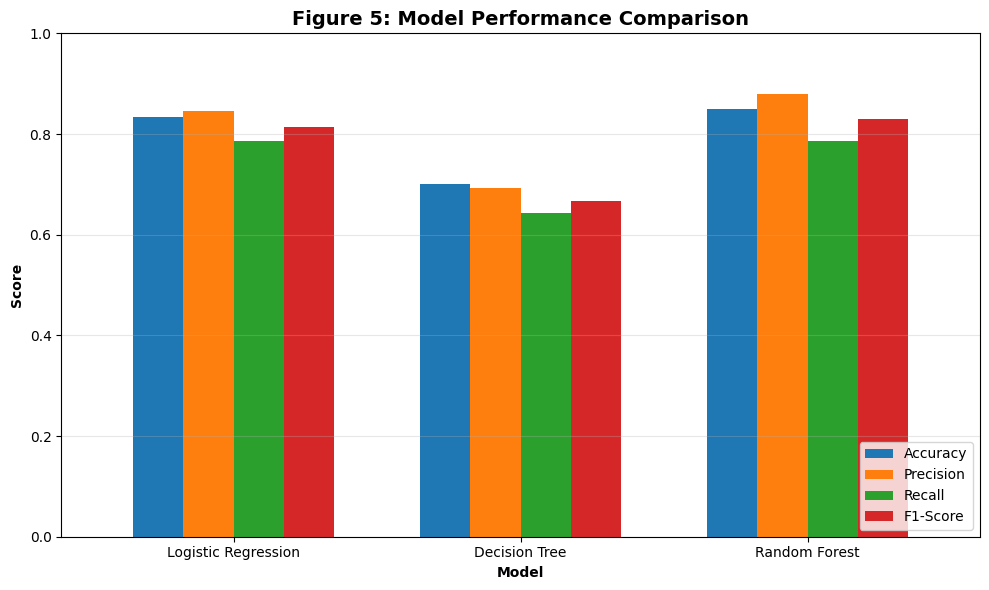

In [ ]:
# Plot bar chart to compare model performance
comparison_df = pd.DataFrame({
    model: {
        'Accuracy': results[model].get('Accuracy', 0),
        'Precision': results[model].get('Precision', 0),
        'Recall': results[model].get('Recall', 0),
        'F1-Score': results[model].get('F1-Score', 0),
        'ROC-AUC': results[model].get('ROC-AUC', 0) if results[model].get('ROC-AUC') is not None else 0
    }
    for model in results.keys()
}).T

comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', figsize=(10, 6), width=0.7
)

plt.title('Figure 5: Model Performance Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontweight='bold')
plt.ylabel('Score', fontweight='bold')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Key Observations from Model Comparison

- Logistic Regression and Random Forest achieved the highest accuracy (83.33%)
- Random Forest showed the highest precision, making it more reliable for detecting heart disease cases
- Logistic Regression achieved the highest ROC-AUC, indicating strong overall classification ability
- Decision Tree performed worse compared to other models

## ROC Curve Analysis

The Receiver Operating Characteristic (ROC) curve is used to evaluate the performance of classification models by illustrating the trade-off between sensitivity (true positive rate) and specificity (false positive rate).

Each curve represents a model’s ability to distinguish between patients with and without heart disease. The performance is summarized using the Area Under the Curve (ROC-AUC):

- A higher ROC-AUC value indicates better model performance
- A value close to 1.0 represents excellent classification ability
- A value of 0.5 represents random guessing

This visualization allows for a direct comparison of how well each model performs across different classification thresholds.

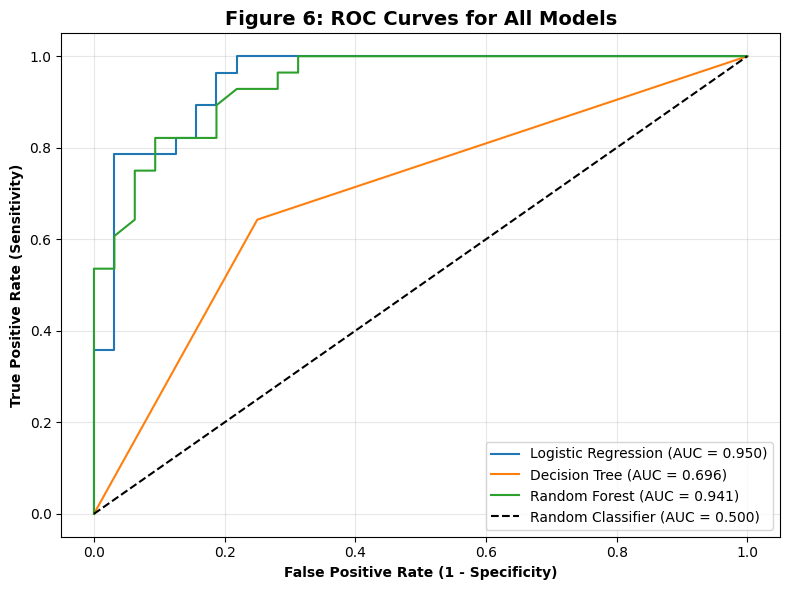

In [ ]:
# Plot ROC curves for all models to compare classification ability
plt.figure(figsize=(8, 6))

for model_name in results.keys():
    if results[model_name]['y_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, results[model_name]['y_proba'])
        auc_score = results[model_name]['ROC-AUC']

        plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.3f})")

# Random baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.500)')

plt.xlabel('False Positive Rate (1 - Specificity)', fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity)', fontweight='bold')
plt.title('Figure 6: ROC Curves for All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

- Logistic Regression and Random Forest show strong ROC curves, indicating high predictive power.
- Both models achieve high AUC values, confirming their reliability in distinguishing between patients with and without heart disease.
- The Decision Tree model performs less effectively, with a lower curve and reduced AUC.

Overall, Logistic Regression and Random Forest are the most suitable models for this task.

## Model Validation using Cross-Validation

To ensure that the selected model performs reliably and is not overfitting the training data, 5-fold cross-validation was applied.

In this approach:
- The dataset is split into 5 subsets (folds)
- The model is trained on 4 folds and tested on the remaining fold
- This process is repeated 5 times

This provides a more robust estimate of model performance compared to a single train-test split.

The mean accuracy and variation across folds help assess the model’s stability and generalization ability.

In [ ]:
# Identify best model based on accuracy
best_model_name = comparison_df['Accuracy'].idxmax()

# Recreate the model (safer than relying on stored object)
if best_model_name == "Logistic Regression":
    best_model = LogisticRegression(max_iter=1000)
    X_used = X_train_scaled
elif best_model_name == "Decision Tree":
    best_model = DecisionTreeClassifier(random_state=42)
    X_used = X_train
elif best_model_name == "Random Forest":
    best_model = RandomForestClassifier(random_state=42)
    X_used = X_train

# Perform 5-fold cross-validation
cv_scores = cross_val_score(best_model, X_used, y_train, cv=5, scoring='accuracy')

print(f"\n5-Fold Cross-Validation for {best_model_name}:")
print(f"Individual fold accuracies: {cv_scores}")
print(f"Mean accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


5-Fold Cross-Validation for Random Forest:
Individual fold accuracies: [0.91666667 0.83333333 0.82978723 0.76595745 0.74468085]
Mean accuracy: 0.8181 (+/- 0.1206)


The cross-validation results show consistent accuracy across folds, indicating that the model generalizes well and is not overfitting.

### Interpretation

The cross-validation results show consistent accuracy across different folds, indicating that the model generalizes well to unseen data.

Low variation between folds suggests that the model is stable and not overly sensitive to specific subsets of the data. This increases confidence in the reliability of the model for real-world applications.

**Policy Implication:**
Healthcare systems should prioritize screening for high-risk individuals based on key predictors identified in this analysis.

## Conclusion

The results demonstrate that machine learning models can effectively predict heart disease using clinical data. Logistic Regression and Random Forest achieved the best performance, while key features such as chest pain type and heart rate were identified as important predictors.

These findings highlight the potential of data mining techniques to support early diagnosis and improve healthcare decision-making.